## Objetivo:
Estudiar cómo el clustering puede ayudarnos cuando tenemos muchas observaciones, pero muy pocas etiquetas.

Trabajaremos con el conjunto de datos `digits`:
*   1,797 imágenes.
*   Dígitos del 0 al 9.
*   Imágenes de 8 × 8 píxeles.
*   64 características por observación.

**Suposición:** Tienes todas las imágenes, pero solamente puedes utilizar 50 etiquetas para entrenar inicialmente el modelo.

In [26]:
from sklearn.datasets import load_digits
X_digits, y_digits = load_digits(
return_X_y=True
)
X_train = X_digits[:1400]
y_train = y_digits[:1400]
X_test = X_digits[1400:]
y_test = y_digits[1400:]

## Visualización de los datos con Reducción de Dimensionalidad

Vamos a aplicar diferentes algoritmos de reducción de dimensionalidad para visualizar la distribución de los dígitos en 2 dimensiones. Esto nos ayudará a entender la estructura de los datos antes de proceder con el clustering y la clasificación.

### t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE es una técnica no lineal de reducción de dimensionalidad utilizada para visualizar conjuntos de datos de alta dimensión. Es particularmente efectiva para revelar agrupaciones en los datos.

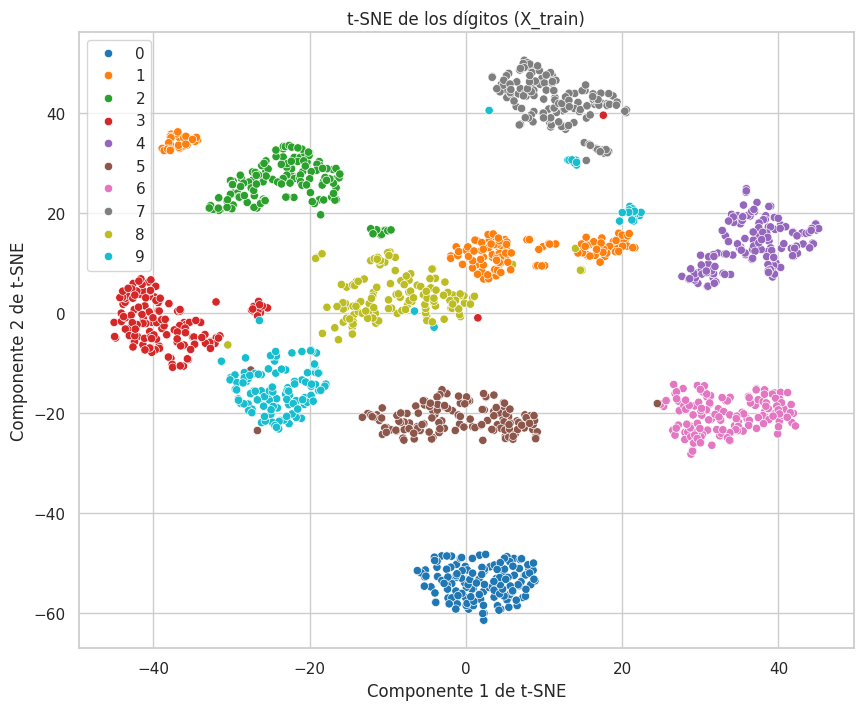

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_train_tsne = tsne.fit_transform(X_train)

# Visualizar los resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_tsne[:, 0],
    y=X_train_tsne[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full'
)
plt.title('t-SNE de los dígitos (X_train)')
plt.xlabel('Componente 1 de t-SNE')
plt.ylabel('Componente 2 de t-SNE')
plt.show()

In [ ]:
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(12, 10))

# 1. Plot all points with lower alpha
sns.scatterplot(
    x=X_train_tsne[:, 0],
    y=X_train_tsne[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full',
    alpha=0.2, # Lower alpha for background points
    s=20, # Smaller points for background scatter
    ax=ax
)

# 2. Select all images to superimpose
# num_total_images_to_show = 100 # Original line for random subset
all_indices = np.arange(len(X_train)) # Use all indices

for i in all_indices:
    x0, y0 = X_train_tsne[i] # t-SNE coordinates
    img = X_train[i].reshape(8, 8) # Original 8x8 image

    # Create an OffsetImage (zoom adjusted for 8x8 images to be visible)
    imagebox = OffsetImage(img, cmap='binary', zoom=1.0)

    # AnnotationBbox to place the image without an arrow and centered on the point
    ab = AnnotationBbox(imagebox, (x0, y0),
                        xycoords='data',
                        xybox=(0,0), # No offset from the data point
                        boxcoords='offset points', # Box coordinates are offset from the data point
                        frameon=False, # No frame around the image
                        pad=0.0
                       )
    ax.add_artist(ab)

ax.set_title('t-SNE de los dígitos (X_train) con todas las imágenes superpuestas') # Updated title
ax.set_xlabel('Componente 1 de t-SNE')
ax.set_ylabel('Componente 2 de t-SNE')
plt.show()

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(12, 10))

# 1. Plot all points with lower alpha
sns.scatterplot(
    x=X_train_tsne[:, 0],
    y=X_train_tsne[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full',
    alpha=0.2, # Lower alpha for background points
    s=20, # Smaller points for background scatter
    ax=ax
)

# 2. Select a subset of images to superimpose
num_total_images_to_show = 100 # Adjust this number to control how many images are shown
random_indices = np.random.choice(len(X_train), num_total_images_to_show, replace=False)

for i in random_indices:
    x0, y0 = X_train_tsne[i] # t-SNE coordinates
    img = X_train[i].reshape(8, 8) # Original 8x8 image

    # Create an OffsetImage (zoom adjusted for 8x8 images to be visible)
    imagebox = OffsetImage(img, cmap='binary', zoom=1.0)

    # AnnotationBbox to place the image without an arrow and centered on the point
    ab = AnnotationBbox(imagebox, (x0, y0),
                        xycoords='data',
                        xybox=(0,0), # No offset from the data point
                        boxcoords='offset points', # Box coordinates are offset from the data point
                        frameon=False, # No frame around the image
                        pad=0.0
                       )
    ax.add_artist(ab)

ax.set_title('t-SNE de los dígitos (X_train) con imágenes superpuestas (muestra aleatoria)')
ax.set_xlabel('Componente 1 de t-SNE')
ax.set_ylabel('Componente 2 de t-SNE')
plt.show()

### Uniform Manifold Approximation and Projection (UMAP)

UMAP es otra técnica de reducción de dimensionalidad no lineal que es computacionalmente más eficiente que t-SNE y a menudo preserva mejor la estructura global de los datos.

In [ ]:
# Instalar umap-learn si no está instalado
!pip install umap-learn

import umap

# Aplicar UMAP
umapper = umap.UMAP(n_components=2, random_state=42)
X_train_umap = umapper.fit_transform(X_train)

# Visualizar los resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_umap[:, 0],
    y=X_train_umap[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full'
)
plt.title('UMAP de los dígitos (X_train)')
plt.xlabel('Componente 1 de UMAP')
plt.ylabel('Componente 2 de UMAP')
plt.show()

### Independent Component Analysis (ICA)

ICA es una técnica que busca descomponer una señal multivariante en componentes aditivas que son estadísticamente tan no gaussianas como sea posible y son mutuamente independientes.

In [ ]:
from sklearn.decomposition import FastICA

# Aplicar ICA
ica = FastICA(n_components=2, random_state=42, max_iter=1000)
X_train_ica = ica.fit_transform(X_train)

# Visualizar los resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_ica[:, 0],
    y=X_train_ica[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full'
)
plt.title('ICA de los dígitos (X_train)')
plt.xlabel('Componente 1 Independiente')
plt.ylabel('Componente 2 Independiente')
plt.show()

### Principal Component Analysis (PCA)

PCA es una técnica lineal de reducción de dimensionalidad que transforma los datos a un nuevo sistema de coordenadas donde las mayores variaciones en los datos se capturan a lo largo del primer eje, la segunda mayor variación a lo largo del segundo, y así sucesivamente.

In [ ]:
from sklearn.decomposition import PCA

# Aplicar PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Visualizar los resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full'
)
plt.title('PCA de los dígitos (X_train)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# Datos etiquetados

Para comenzar, supón que únicamente tienes disponibles las etiquetas de 50 observaciones:

```python
n_labeled = 50
```

**Importante:** Utiliza `y_test` solamente para evaluar los modelos.

In [ ]:
n_labeled=50

In [ ]:
from sklearn.linear_model import \
LogisticRegression
log_reg = LogisticRegression(
max_iter=10_000
)
log_reg.fit(
X_train[:n_labeled],
y_train[:n_labeled]
)
accuracy = log_reg.score(
X_test,
y_test
)
print(accuracy)

En el experimento anterior utilizamos simplemente las primeras 50 observaciones.

Sin embargo, si solamente podemos etiquetar un número pequeño de observaciones, nos conviene seleccionar ejemplos que sean representativos del conjunto de datos.

La idea será:
1.  Agrupar los datos utilizando K-means.
2.  Encontrar una observación representativa de cada cluster.
3.  Utilizar esas observaciones para entrenar el clasificador.

El mas representativo es la media, y el mas cercano a la media es llamado **meoide**.

In [ ]:
from sklearn.cluster import KMeans
k = 50
kmeans = KMeans(
n_clusters=k,
random_state=42
)

X_digits_dist = kmeans.fit_transform(
X_train
)

Agrupa las 1,400 observaciones de entrenamiento en 50 clusters:

El resultado `X_digits_dist` contiene las distancias de cada observación a cada uno de los 50 centroides.

Para cada cluster, selecciona la observación más cercana a su centroide:

In [ ]:
representative_digit_idx = \
X_digits_dist.argmin(axis=0)
X_representative_digits = \
X_train[representative_digit_idx]

Ahora tienes exactamente **50** imágenes representativas, una por cada cluster.

Visualiza estas 50 imágenes antes de continuar.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5)) # Adjusted figure size for better display
for index, X_representative_digit in enumerate(X_representative_digits):
  plt.subplot(k // 10, 10, index + 1) # k=50 means 5 rows, 10 columns
  plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary" ,interpolation="bilinear")
  plt.axis('off')
plt.tight_layout() # Adjust layout to prevent overlapping subplots
plt.show()

In [ ]:
import numpy as np
y_representative_digits = np.array([
8, 0, 1, 3, 6, 7, 5, 4, 2, 8,
2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
4, 6, 9, 7, 5, 2, 2, 1, 3, 3,
6, 0, 4, 9, 8, 1, 8, 4, 2, 4,
2, 3, 9, 7, 8, 9, 6, 5, 6, 4,
])

Estas etiquetas corresponden, en el mismo orden, a las 50 imágenes representativas obtenidas con K-means (asegúrate de que las etiquetas sean correctas).

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits,y_representative_digits)
accuracy_representative = log_reg.score(X_test,y_test)
print(accuracy_representative)

### Selección de Meoides en el espacio UMAP

Ahora, aplicaremos K-means en los datos transformados por UMAP (`X_train_umap`) para identificar los 50 *meoides* (observaciones más cercanas a los centroides) que serán utilizados para entrenar el modelo.

In [ ]:
from sklearn.cluster import KMeans

# Aplicar K-means en el espacio UMAP
k_umap = 50 # Ya definido anteriormente, pero para claridad
kmeans_umap = KMeans(
    n_clusters=k_umap,
    random_state=42,
    n_init='auto' # Auto initialization
)
kmeans_umap.fit(X_train_umap)

# Calcular las distancias de cada observación a los centroides en el espacio UMAP
X_train_umap_dist = kmeans_umap.transform(X_train_umap)

# Seleccionar la observación más cercana a cada centroide (el meoide)
representative_digit_idx_umap = X_train_umap_dist.argmin(axis=0)
X_representative_digits_umap = X_train_umap[representative_digit_idx_umap]
y_representative_digits_umap = y_train[representative_digit_idx_umap]

print(f"Se han seleccionado {len(X_representative_digits_umap)} dígitos representativos en el espacio UMAP.")

### Entrenamiento de Regresión Logística con Meoides del espacio UMAP

Entrenaremos un nuevo modelo de Regresión Logística utilizando estas 50 observaciones representativas del espacio UMAP y evaluaremos su precisión en el conjunto de prueba, previamente transformado con UMAP.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg_umap = LogisticRegression(
    max_iter=10_000
)

log_reg_umap.fit(
    X_representative_digits_umap,
    y_representative_digits_umap
)

# Transformar X_test usando el mismo modelo UMAP ajustado a X_train
X_test_umap = umapper.transform(X_test)

accuracy_representative_umap = log_reg_umap.score(
    X_test_umap,
    y_test
)
print(f"Precisión del clasificador con meoides UMAP: {accuracy_representative_umap}")

Compara:
50 ejemplos iniciales vs. 50 ejemplos representativos.
¿Mejoró la exactitud?

Contesta:
¿Cuál fue la exactitud utilizando las primeras 50
observaciones?
¿Cuál fue la exactitud utilizando las 50 observaciones
representativas?
¿Qué estrategia funcionó mejor?
¿Por qué seleccionar observaciones cercanas a los
centroides puede producir un mejor conjunto de
entrenamiento?
La cantidad de etiquetas utilizadas sigue siendo la misma:
50.
Lo único que cambió fue qué observaciones etiquetadas
utilizamos.

## Propagación de etiquetas

Supón ahora que todos los ejemplos pertenecientes a un mismo cluster tienen la etiqueta de su ejemplo representativo.

**Propaga las etiquetas:**

Ahora tienes una etiqueta estimada para las 1,400 observaciones de entrenamiento.

In [ ]:
import numpy as np

y_train_propagated = np.empty(
    len(X_train),
    dtype=np.int64
)

for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train,y_train_propagated)
accuracy_propagated = log_reg.score(X_test,y_test)
print(f"Precisión con etiquetas propagadas: {accuracy_propagated}")

Al propagar las etiquetas estamos suponiendo que:

*   Observaciones del mismo cluster = misma clase.

**Contesta:**
1.  ¿Es siempre válido este supuesto?
2.  ¿Puede un cluster contener imágenes de distintos dígitos?
3.  ¿En qué parte del cluster esperarías encontrar observaciones menos confiables?

Esto nos lleva al siguiente experimento.

## Propagación parcial

En lugar de propagar la etiqueta a todo el cluster, propágala solamente a las observaciones más cercanas al centroide.

Conserva únicamente el **50%** de las observaciones más cercanas al centroide de cada cluster.

La idea es eliminar observaciones alejadas del centroide, que pueden ser menos representativas del cluster.

Obtén la distancia de cada observación al centroide de su propio cluster:

Después, para cada cluster, calcula el percentil 50 de las distancias y elimina las observaciones que se encuentren más lejos.

In [ ]:
percentile_closest = 50

X_cluster_dist = X_digits_dist[
    np.arange(len(X_train)),
    kmeans.labels_
]

In [ ]:
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist,percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

Selecciona únicamente las observaciones que no fueron eliminadas:

Ahora tienes un conjunto de entrenamiento más pequeño, pero con etiquetas propagadas únicamente a observaciones relativamente cercanas al centroide.

In [ ]:
partially_propagated = (
    X_cluster_dist != -1
)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [ ]:
log_reg = LogisticRegression(
    max_iter=10_000
)
log_reg.fit(
    X_train_partially_propagated,
    y_train_partially_propagated
)
accuracy_partial = log_reg.score(
    X_test,
    y_test
)
print(f"Precisión con propagación parcial: {accuracy_partial}")

## Tabla de resultados

Identifica cuál de los cuatro métodos produjo la mayor exactitud.

In [ ]:
import pandas as pd

accuracies = {
    "50 observaciones iniciales": accuracy,
    "50 observaciones representativas": accuracy_representative,
    "50 observaciones representativas UMAP": accuracy_representative_umap,
    "Propagación de etiquetas": accuracy_propagated,
    "Propagación parcial": accuracy_partial
}

# Convertir a pandas DataFrame para una mejor visualización
accuracies_df = pd.DataFrame(accuracies.items(), columns=['Estrategia', 'Precisión'])
display(accuracies_df.sort_values(by='Precisión', ascending=False))

**Contesta brevemente:**

1.  ¿Por qué las 50 observaciones representativas pueden ser mejores que las primeras 50 observaciones?
2.  ¿Qué representa una imagen representativa de un cluster?
3.  ¿Qué supuesto hacemos al propagar la etiqueta de la imagen representativa a todo el cluster?
4.  ¿Por qué este supuesto puede fallar?
5.  ¿Por qué conservar únicamente las observaciones cercanas al centroide puede mejorar los resultados?
6.  ¿Qué método obtuvo la mayor exactitud?